**Phase 0 : Imports and Reading Data:**

 - Upload dataset into Google Colab.

 - Import essential libraries: pandas, numpy, matplotlib, seaborn.

 - Load the dataset (housing.csv) into a DataFrame.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing (13).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('housing.csv')

**Phase 1: Data Cleaning & Exploratory Data Analysis (EDA):**

 - Check column types (numerical, categorical) and handle the wrong assigned types.

 - Handle missing values if present.

 - Visualize data distribution with histograms.

 - Explore relationships and correlations using scatter plots and heatmaps.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
print(df['median_house_value'].unique())

print(df['households'].unique())

[452600. 358500. 352100. ... 425800. 200700.  47000.]
[ 126. 1138.  177. ... 1767. 1832. 1818.]


Here, we had a look upon median_house_value and households uniqe values to check the data type which is assined shold be float or integer

In [ ]:
df.dropna(subset=['total_bedrooms'], inplace=True)
df = df.astype({'total_bedrooms': 'int64', 'housing_median_age': 'int64' , 'total_rooms': 'int64' ,'total_bedrooms' : 'int64', 'population': 'int64', 'households': 'int64', 'median_house_value' : 'int64'})


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  int64  
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  int64  
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(3), int64(6), object(1)
memory usage: 1.7+ MB


Our dataset now is clean form missing values and wrong data types, it was pretty simple this time ✅


---



**Phase 2: Data processing & feature engineering:**
 - split the dataset into training and testing sets (80/20).
 - After splitting (usually only on the training set), we create new features or transform existing ones to better represent the data.



In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop('median_house_value', axis=1)
y = df['median_house_value']
y = np.log1p(y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
data_train = x_train.join(y_train)
data_test = x_test.join(y_test)
data_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
17727,-121.80,37.32,14,4412,924,2698,891,4.7027,<1H OCEAN,12.335349
2057,-119.63,36.64,33,1036,181,620,174,3.4107,INLAND,11.611874
6453,-118.06,34.12,25,3891,848,1848,759,3.6639,INLAND,12.421591
4619,-118.31,34.07,28,2362,949,2759,894,2.2364,<1H OCEAN,12.630036
15266,-117.27,33.04,27,1839,392,1302,404,3.5500,NEAR OCEAN,12.276536
...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24,2991,500,1437,453,5.4286,<1H OCEAN,12.518695
12081,-117.54,33.76,5,5846,1035,3258,1001,4.7965,<1H OCEAN,11.987923
5447,-118.42,34.01,42,1594,369,952,362,3.0990,<1H OCEAN,12.723082
866,-122.04,37.57,12,5719,1064,3436,1057,5.2879,NEAR BAY,12.351043


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

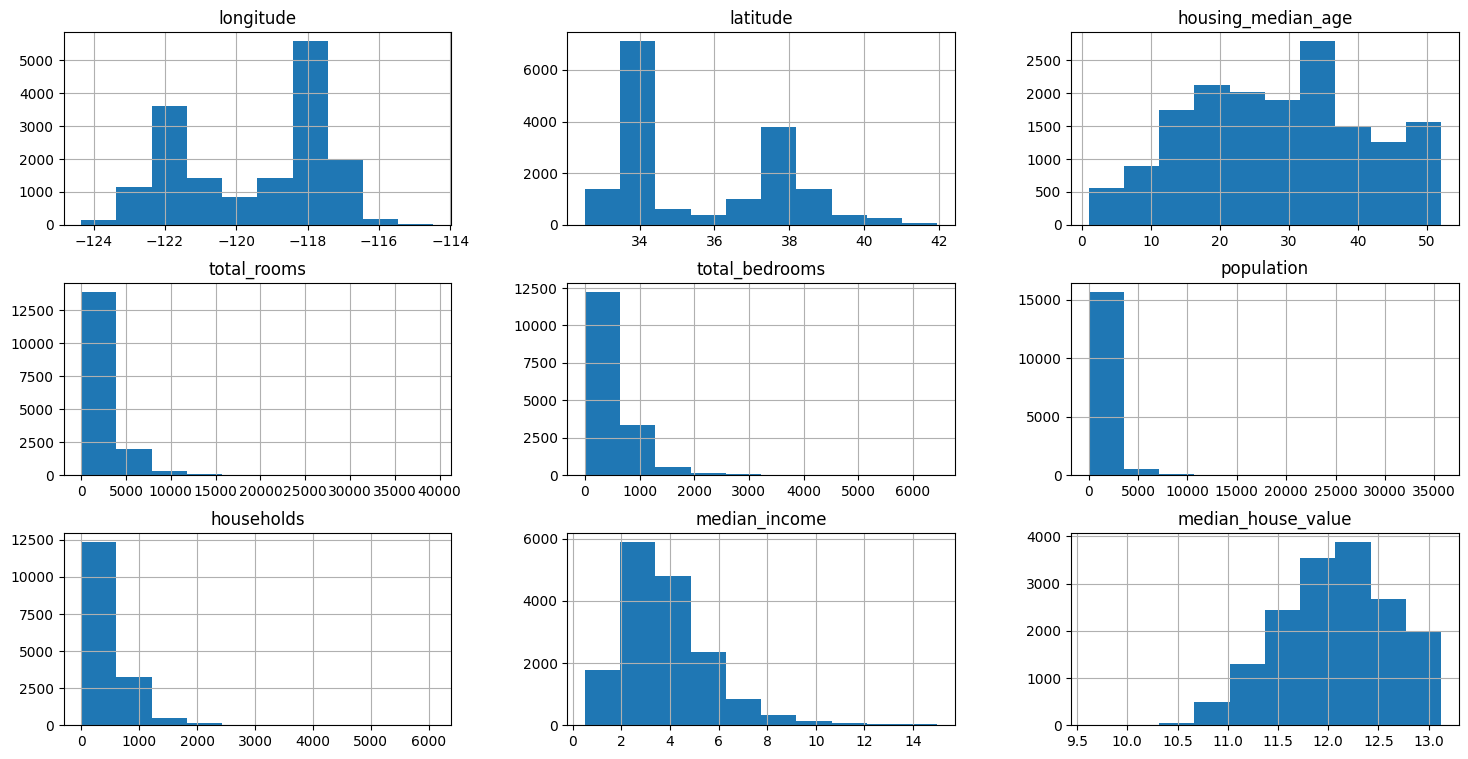

In [ ]:
data_train.hist(figsize=(18,9))




---


The feature **ocean_proximity** is categorical (e.g., "NEAR BAY", "INLAND"), and machine learning models require numerical input. Therefore, we encode this feature into numeric values so the model can process it effectively.

Encoding also allows us to include ocean_proximity in correlation analysis (e.g., via a heatmap) to better understand its relationship with other features and the target variable.

In [ ]:
data_train= data_train.join(pd.get_dummies(data_train['ocean_proximity'])).drop('ocean_proximity', axis=1)
data_test= data_test.join(pd.get_dummies(data_test['ocean_proximity'])).drop('ocean_proximity', axis=1)
data_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
17727,-121.80,37.32,14,4412,924,2698,891,4.7027,12.335349,True,False,False,False,False
2057,-119.63,36.64,33,1036,181,620,174,3.4107,11.611874,False,True,False,False,False
6453,-118.06,34.12,25,3891,848,1848,759,3.6639,12.421591,False,True,False,False,False
4619,-118.31,34.07,28,2362,949,2759,894,2.2364,12.630036,True,False,False,False,False
15266,-117.27,33.04,27,1839,392,1302,404,3.5500,12.276536,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24,2991,500,1437,453,5.4286,12.518695,True,False,False,False,False
12081,-117.54,33.76,5,5846,1035,3258,1001,4.7965,11.987923,True,False,False,False,False
5447,-118.42,34.01,42,1594,369,952,362,3.0990,12.723082,True,False,False,False,False
866,-122.04,37.57,12,5719,1064,3436,1057,5.2879,12.351043,False,False,False,True,False


<Axes: >

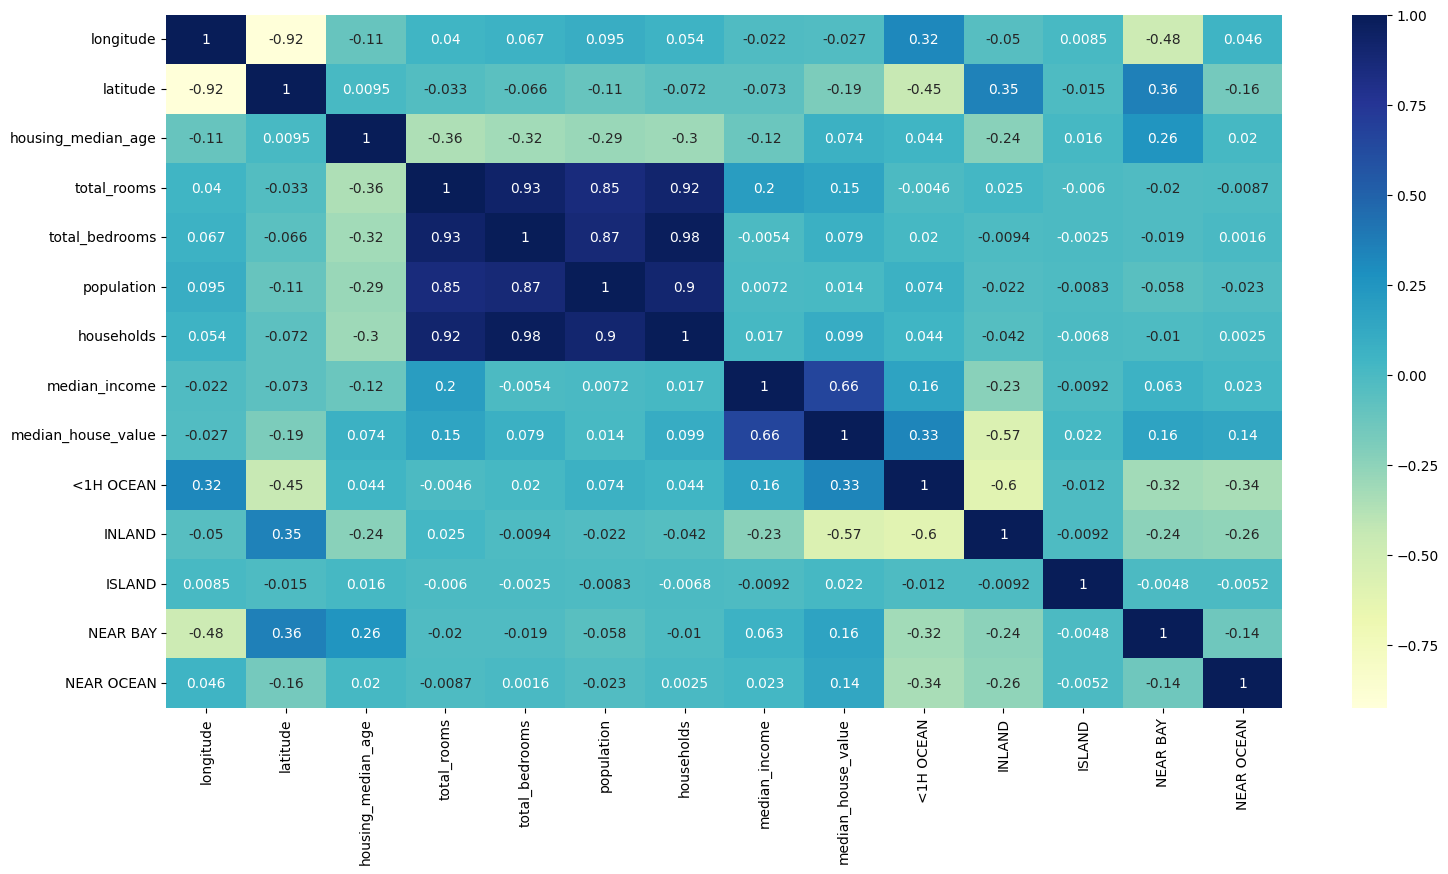

In [ ]:
plt.figure(figsize=(18,9))
sns.heatmap(data_train.corr(),annot=True,cmap='YlGnBu')

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

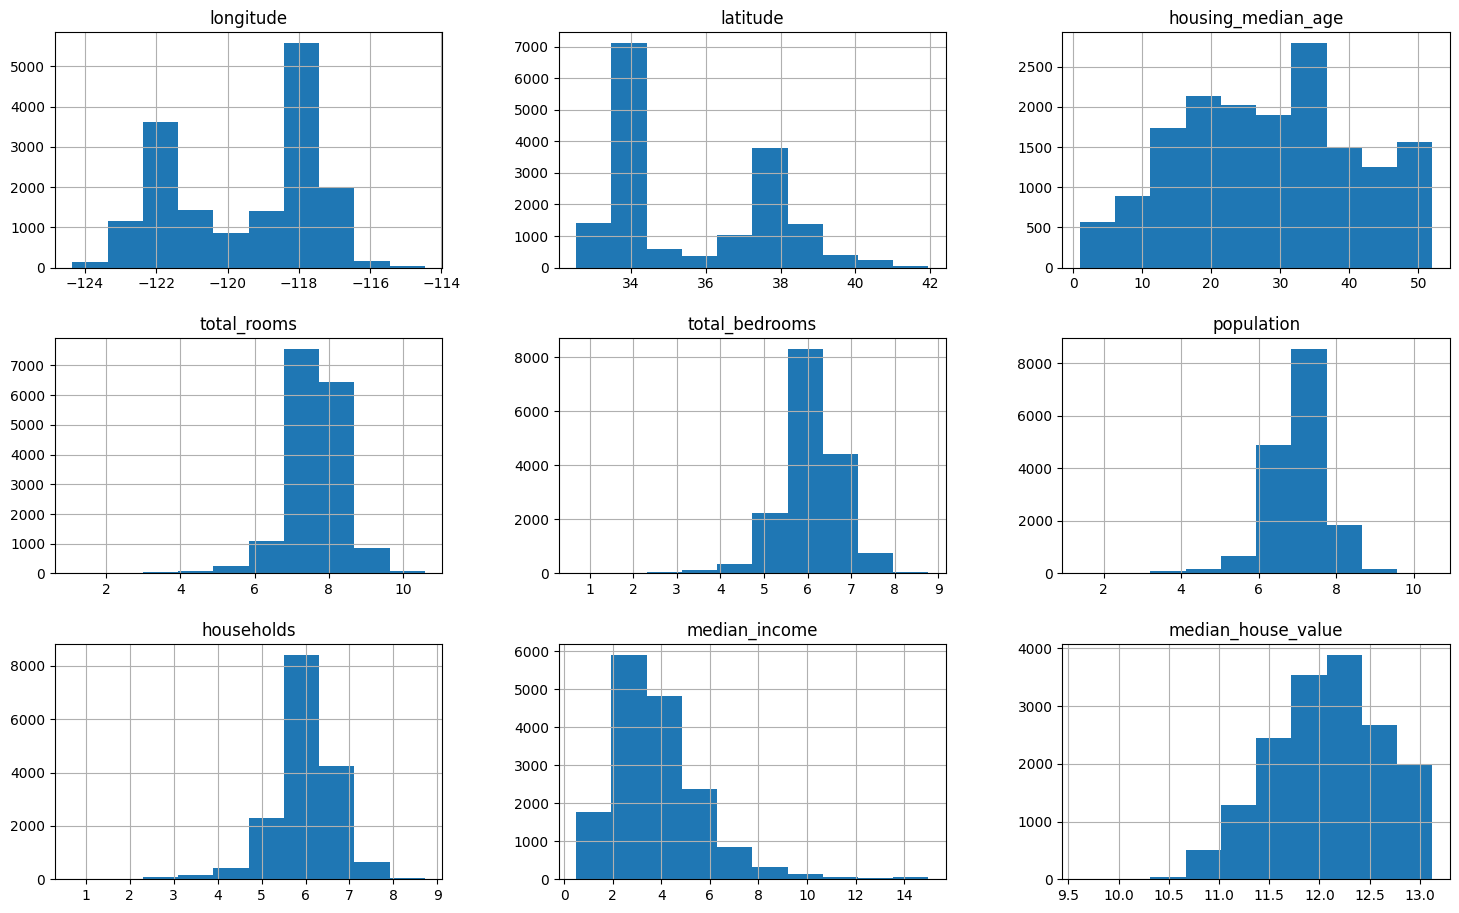

In [ ]:
data_train['total_rooms']= np.log(data_train['total_rooms']+1)
data_train['total_bedrooms']= np.log(data_train['total_bedrooms']+1)
data_train['population']= np.log(data_train['population']+1)
data_train['households']= np.log(data_train['households']+1)
data_test['total_rooms']= np.log(data_test['total_rooms']+1)
data_test['total_bedrooms']= np.log(data_test['total_bedrooms']+1)
data_test['population']= np.log(data_test['population']+1)
data_test['households']= np.log(data_test['households']+1)
data_train.hist(figsize=(18,11))

**This step normalizes skewed features, reduces outlier effect, and helps the model learn patterns more effectively.** ✅

<Axes: xlabel='longitude', ylabel='latitude'>

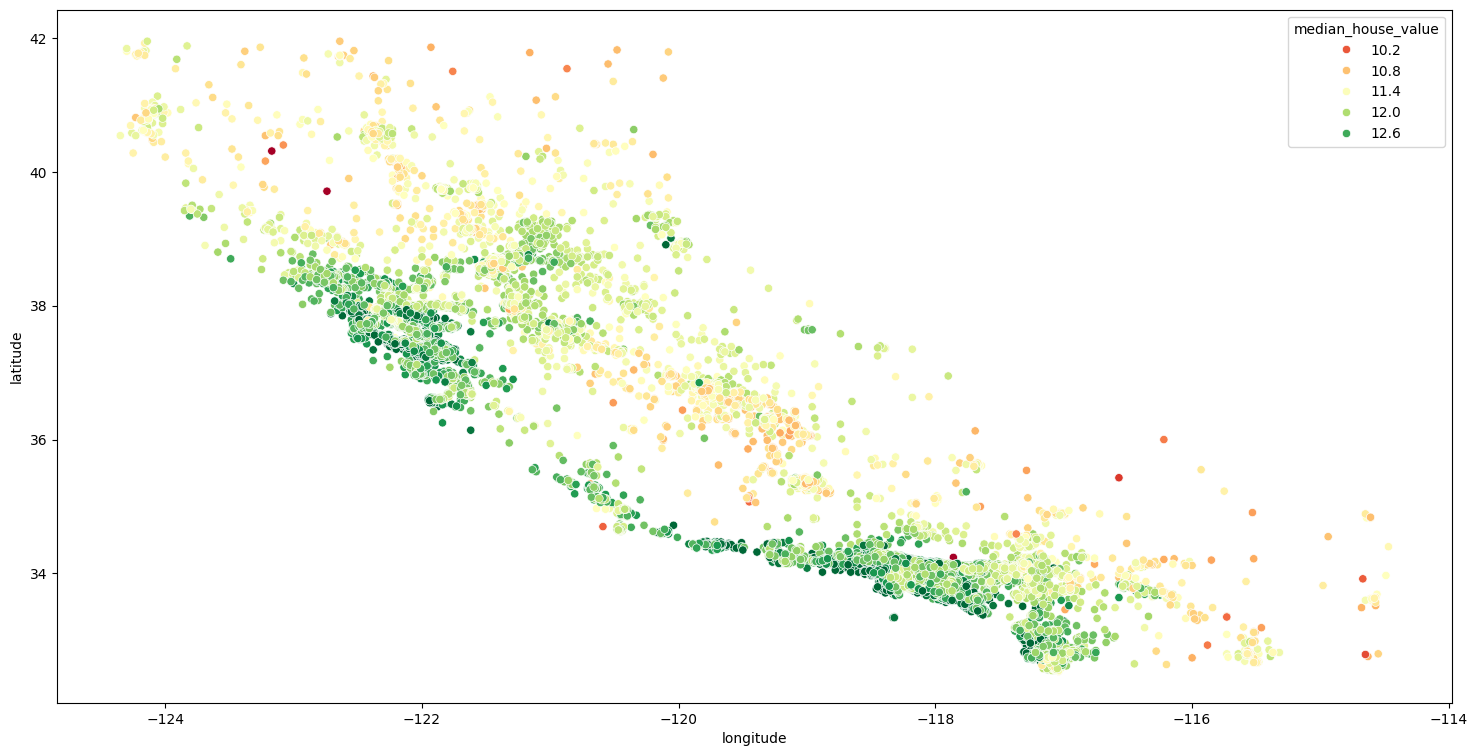

In [ ]:
plt.figure(figsize=(18,9))
sns.scatterplot(data=data_train,x='longitude',y='latitude',hue='median_house_value',palette='RdYlGn')

In [ ]:
data_train['bedrooms_ratio']= data_train['total_bedrooms']/data_train['total_rooms']
data_train['household_rooms']= data_train['total_rooms']/data_train['households']
data_train['population_per_household']= data_train['population']/data_train['households']
data_test['bedrooms_ratio']= data_test['total_bedrooms']/data_test['total_rooms']
data_test['household_rooms']= data_test['total_rooms']/data_test['households']
data_test['population_per_household']= data_test['population']/data_test['households']
data_train['income_per_household'] = data_train ['median_income'] /data_train['households']
data_train['rooms_per_person'] = data_train['total_rooms'] / data_train['population']
data_test['income_per_household'] = data_test ['median_income'] /data_test['households']
data_test['rooms_per_person'] = data_test['total_rooms'] / data_test['population']

data_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_ratio,household_rooms,population_per_household,income_per_household,rooms_per_person
17727,-121.80,37.32,14,8.392310,6.829794,7.900637,6.793466,4.7027,12.335349,True,False,False,False,False,0.813816,1.235350,1.162976,0.692239,1.062232
2057,-119.63,36.64,33,6.944087,5.204007,6.431331,5.164786,3.4107,11.611874,False,True,False,False,False,0.749416,1.344506,1.245227,0.660376,1.079728
6453,-118.06,34.12,25,8.266678,6.744059,7.522400,6.633318,3.6639,12.421591,False,True,False,False,False,0.815812,1.246236,1.134033,0.552348,1.098942
4619,-118.31,34.07,28,7.767687,6.856462,7.922986,6.796824,2.2364,12.630036,True,False,False,False,False,0.882690,1.142841,1.165689,0.329036,0.980399
15266,-117.27,33.04,27,7.517521,5.973810,7.172425,6.003887,3.5500,12.276536,False,False,False,False,True,0.794652,1.252109,1.194630,0.591284,1.048114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24,8.003697,6.216606,7.271009,6.118097,5.4286,12.518695,True,False,False,False,False,0.776717,1.308200,1.188443,0.887302,1.100769
12081,-117.54,33.76,5,8.673684,6.943122,8.089176,6.909753,4.7965,11.987923,True,False,False,False,False,0.800481,1.255281,1.170690,0.694164,1.072258
5447,-118.42,34.01,42,7.374629,5.913503,6.859615,5.894403,3.0990,12.723082,True,False,False,False,False,0.801871,1.251124,1.163751,0.525753,1.075079
866,-122.04,37.57,12,8.651724,6.970730,8.142354,6.964136,5.2879,12.351043,False,False,False,True,False,0.805704,1.242326,1.169184,0.759305,1.062558


creatig new features to better represent the data. ✈

<Axes: >

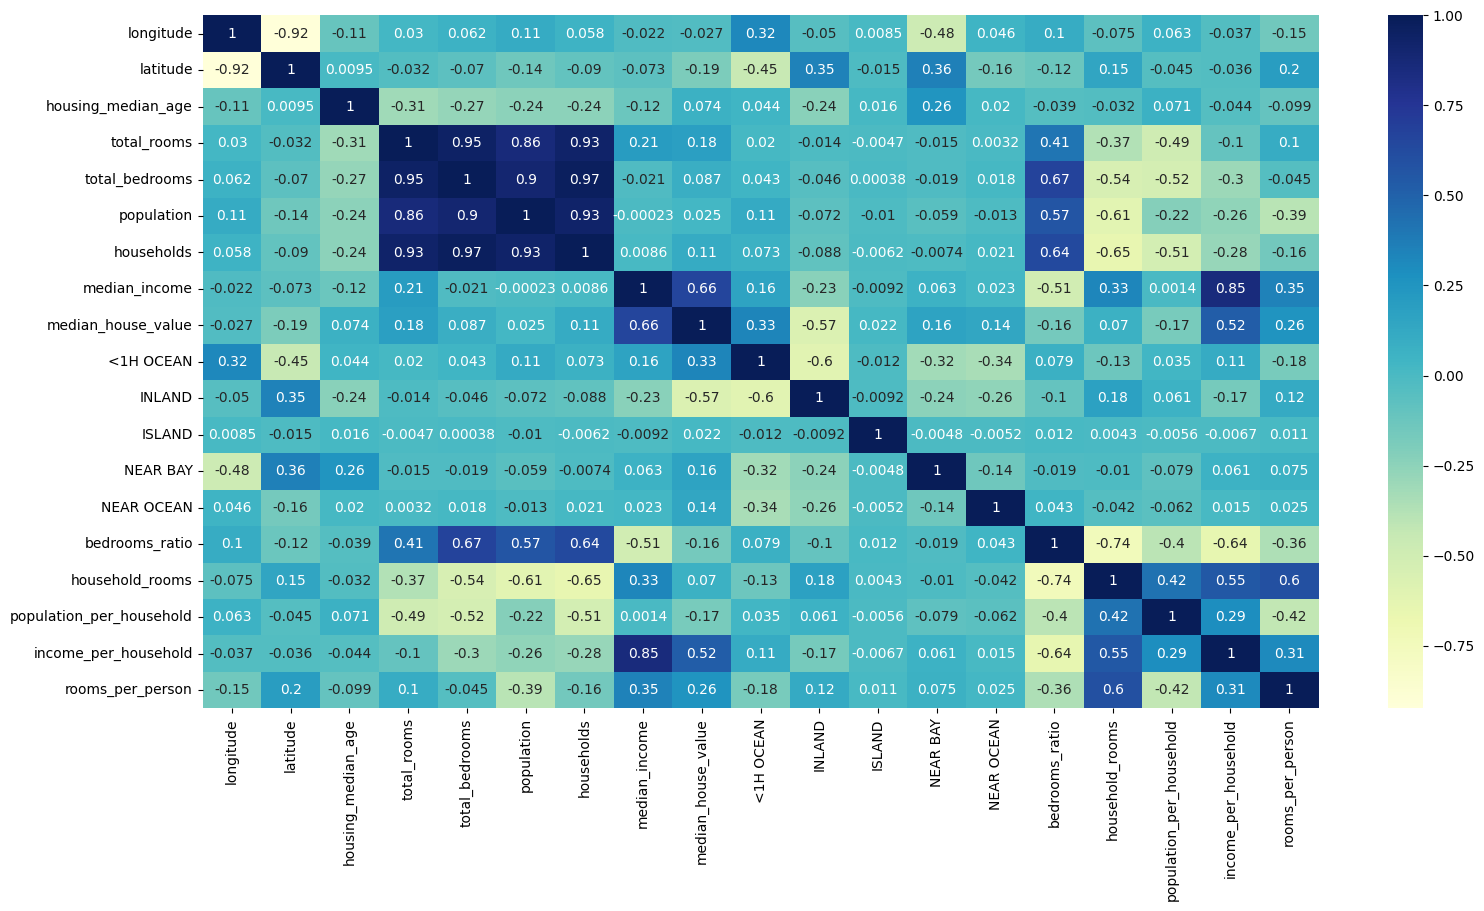

In [ ]:
plt.figure(figsize=(18,9))
sns.heatmap(data_train.corr(),annot=True,cmap='YlGnBu')



---



---


**Phase 3: Training phase:**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
x_train, y_train = data_train.drop('median_house_value', axis=1), data_train['median_house_value']
x_test, y_test = data_test.drop('median_house_value', axis=1), data_test['median_house_value']
x_train_s = scaler.fit_transform(x_train)



reg = LinearRegression()

reg.fit(x_train_s, y_train)


LinearRegression()

In [ ]:
x_test_s = scaler.transform(x_test)

In [ ]:
reg.score(x_test_s, y_test)


0.6960427429115162

In [ ]:
from sklearn.ensemble import RandomForestRegressor

ran = RandomForestRegressor()

ran.fit(x_train_s, y_train)



RandomForestRegressor()

In [ ]:
ran.score(x_test_s, y_test)

0.8351382676121819

In [ ]:
from sklearn.model_selection import RandomizedSearchCV , GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    rf, rf_params, n_iter=2, cv=3, scoring="r2",
    n_jobs=-1, random_state=42, verbose=2
)
rf_random.fit(x_train, y_train)

best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(x_test)
rf_score = r2_score(y_test, y_pred_rf)
rf_score

Fitting 3 folds for each of 2 candidates, totalling 6 fits


0.8326749225759382

In [423]:
import joblib
model_filename= 'housing_price_Prediction.pkl'
joblib.dump(ran, model_filename) # Save the model object instead of the score
print(f"Final model saved to '{model_filename}' successfully!")
print("You can download this file from your environment")

Final model saved to 'housing_price_Prediction.pkl' successfully!
You can download this file from your environment


In [ ]:
new_data = pd.DataFrame([{
    "longitude": -121.89,
    "latitude": 37.34,
    "housing_median_age": 25,
    "total_rooms": 3500.0,
    "total_bedrooms": 700.0,
    "population": 1500.0,
    "households": 500.0,
    "median_income": 6.2,
    "<1H OCEAN": True,
    "INLAND": False,
    "ISLAND": False,
    "NEAR BAY": False,
    "NEAR OCEAN": False,
    "bedrooms_ratio": 0.20,
    "household_rooms": 7.0,
    "population_per_household": 3.0,
    "income_per_household": 12400.0,
    "rooms_per_person": 2.33
}])
loaded_model = joblib.load(model_filename)
predicted_price = loaded_model.predict(new_data)


In this project, the housing dataset was used to predict median house values based on demographic and geographic features. A series of preprocessing steps were applied, including handling missing values, encoding categorical variables, creating new features, and applying log transformation to the target variable. Outliers were also examined using IQR and boxplots, and treated with capping and log scaling.


Several machine learning algorithms were tested to evaluate performance. Linear Regression was used as a baseline model and achieved relatively low accuracy. RandomForest Regressor proved to be the most effective model, reaching anscore of ✅ **0.835** ✅ after applying log transformation and feature engineering. Attempts were made to train more advanced models and to perform hyperparameter tuning using GridSearchCV and RandomizedSearchCV, but these approaches could not be completed successfully due to hardware and time limitations.


The main takeaway is that tree-based models are robust to outliers, so advanced outlier handling did not yield significant improvements. However, log-transforming the target variable played a crucial role in boosting the accuracy of the RandomForest model.  

